In [14]:
import os

In [15]:
print("Файлы в корне Google Диска:")
for item in os.listdir('/content/drive/MyDrive/'):
    print(f"  - {item}")

Файлы в корне Google Диска:
  - Colab Notebooks
  - Classroom
  - LB1
  - laptop_price_model.pkl
  - Новый документ.gdoc
  - 2_5370603900657242148 (2).gdoc
  - 2_5370603900657242148 (1).gdoc
  - 2_5370603900657242148.gdoc
  - Лаб 1-2.gdoc
  - 2_5204263433645627056.gdoc
  - Отчет лб3-4 Драгомир.docx
  - food_c101_n1000_r384x384x3.h5.zip


In [16]:
print("\nПоиск файлов food_c101...")
found_files = []
for root, dirs, files in os.walk('/content/drive/MyDrive/'):
    for file in files:
        if 'food_c101' in file and file.endswith('.zip'):
            found_files.append(os.path.join(root, file))
            print(f"Найден файл: {os.path.join(root, file)}")

if not found_files:
    print("Файлы food_c101 не найдены. Проверь, точно ли файл загружен в корень или папку на диске.")


Поиск файлов food_c101...
Найден файл: /content/drive/MyDrive/food_c101_n1000_r384x384x3.h5.zip


In [17]:
!cp "/content/drive/MyDrive/food_c101_n1000_r384x384x3.h5.zip" "./"


In [18]:
import os
if os.path.exists('food_c101_n1000_r384x384x3.h5.zip'):
    print("✅ Файл успешно скопирован!")
    print(f"Размер файла: {os.path.getsize('food_c101_n1000_r384x384x3.h5.zip') / 1024**2:.2f} МБ")
else:
    print("❌ Файл не скопирован. Проверь имя файла.")

✅ Файл успешно скопирован!
Размер файла: 342.70 МБ


In [19]:
import zipfile


In [20]:
print("Распаковка архива...")
with zipfile.ZipFile('food_c101_n1000_r384x384x3.h5.zip', 'r') as zip_ref:
    zip_ref.extractall('./food_dataset')
print("✅ Распаковка завершена!")


Распаковка архива...
✅ Распаковка завершена!


In [21]:
print("\nСодержимое папки food_dataset:")
for item in os.listdir('./food_dataset'):
    print(f"  - {item}")


Содержимое папки food_dataset:
  - food_c101_n1000_r384x384x3.h5


In [22]:
import h5py

In [23]:
h5_files = []
for root, dirs, files in os.walk('./food_dataset'):
    for file in files:
        if file.endswith('.h5'):
            h5_files.append(os.path.join(root, file))

if h5_files:
    print(f"Найдено {len(h5_files)} HDF5 файлов:")
    for f in h5_files:
        print(f"  - {os.path.basename(f)}")

    # Открываем первый файл
    with h5py.File(h5_files[0], 'r') as f:
        print(f"\n📊 Структура файла {os.path.basename(h5_files[0])}:")
        print(f"Ключи в файле: {list(f.keys())}")

        if 'images' in f:
            print(f"  - Изображения: {f['images'].shape}")
            print(f"    Тип данных: {f['images'].dtype}")
        if 'labels' in f:
            print(f"  - Метки: {f['labels'].shape}")
            print(f"    Тип данных: {f['labels'].dtype}")
else:
    print("❌ HDF5 файлы не найдены. Проверь распаковку.")

Найдено 1 HDF5 файлов:
  - food_c101_n1000_r384x384x3.h5

📊 Структура файла food_c101_n1000_r384x384x3.h5:
Ключи в файле: ['category', 'category_names', 'images']
  - Изображения: (1000, 384, 384, 3)
    Тип данных: uint8


In [25]:
import h5py

# Открываем файл и смотрим все ключи
with h5py.File(h5_files[0], 'r') as f:
    print("🔑 Все ключи в файле:", list(f.keys()))

    # Проверяем каждый ключ
    for key in f.keys():
        print(f"\nКлюч: {key}")
        print(f"  - Форма: {f[key].shape}")
        print(f"  - Тип данных: {f[key].dtype}")
        print(f"  - Первые 5 значений: {f[key][:5]}")

🔑 Все ключи в файле: ['category', 'category_names', 'images']

Ключ: category
  - Форма: (1000, 101)
  - Тип данных: bool
  - Первые 5 значений: [[False False False False False False False False False False False False
  False  True False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False]
 [False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False  True False False
  False 

In [27]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Открываем файл
with h5py.File(h5_files[0], 'r') as f:
    images = f['images'][:]                    # Изображения (1000, 384, 384, 3)
    category = f['category'][:]                # One-hot метки (1000, 101)
    category_names = f['category_names'][:]    # Названия классов (101,)

# Преобразуем one-hot в обычные метки (индексы классов)
labels = np.argmax(category, axis=1)

# Декодируем названия классов из байтового формата
class_names = [name.decode('utf-8') for name in category_names]

print(f"✅ Загружено {len(images)} изображений")
print(f"Количество классов: {len(class_names)}")
print(f"Первые 5 классов: {class_names[:5]}")
print(f"Диапазон значений пикселей: от {images.min()} до {images.max()}")
print(f"Тип данных изображений: {images.dtype}")

✅ Загружено 1000 изображений
Количество классов: 101
Первые 5 классов: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']
Диапазон значений пикселей: от 0 до 255
Тип данных изображений: uint8


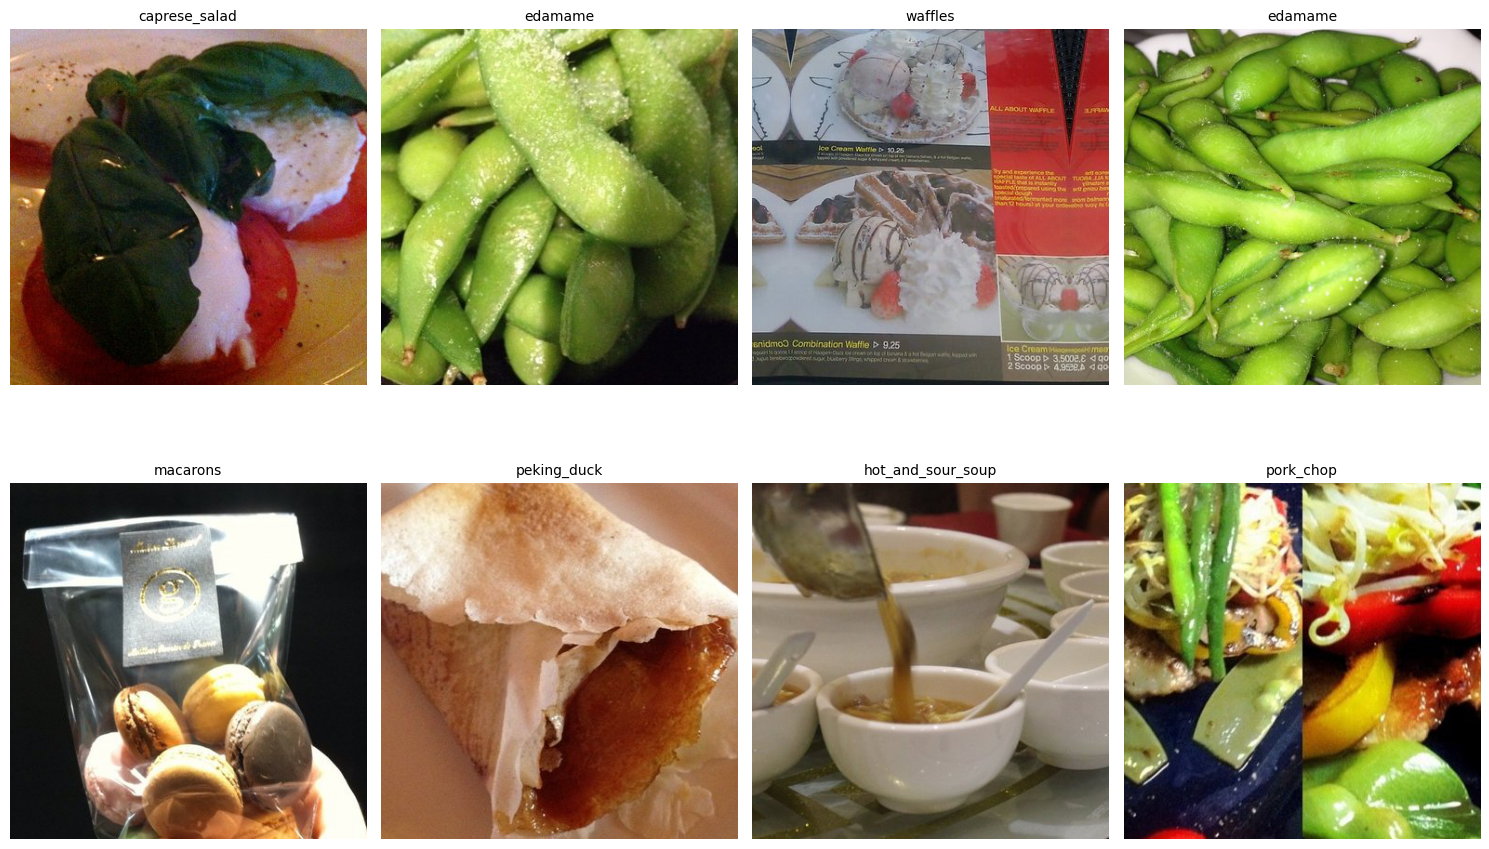


Всего уникальных классов в этом файле: 101
Количество изображений на класс: 9 (должно быть 1000)


In [28]:
plt.figure(figsize=(15, 10))
for i in range(8):
    plt.subplot(2, 4, i+1)
    img = images[i]
    # Если значения uint8, они уже в диапазоне 0-255
    plt.imshow(img)
    # Получаем название класса
    class_idx = labels[i]
    class_name = class_names[class_idx]
    plt.title(f'{class_name}', fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Выводим информацию о распределении классов
unique, counts = np.unique(labels, return_counts=True)
print(f"\nВсего уникальных классов в этом файле: {len(unique)}")
print(f"Количество изображений на класс: {counts[0]} (должно быть 1000)")

In [29]:
print("📁 Все файлы в папке food_dataset:")
for item in os.listdir('./food_dataset'):
    print(f"  - {item}")
    if item.endswith('.h5'):
        # Проверяем размер каждого файла
        size_mb = os.path.getsize(f'./food_dataset/{item}') / 1024**2
        print(f"    Размер: {size_mb:.2f} МБ")

📁 Все файлы в папке food_dataset:
  - food_c101_n1000_r384x384x3.h5
    Размер: 342.76 МБ


In [30]:
import os

print("🔍 Поиск всех файлов Food-101 на Google Диске:")
found_all = []
for root, dirs, files in os.walk('/content/drive/MyDrive/'):
    for file in files:
        if 'food' in file.lower() and (file.endswith('.h5') or file.endswith('.zip')):
            found_all.append(os.path.join(root, file))
            print(f"  - {os.path.basename(file)}")
            print(f"    Путь: {os.path.join(root, file)}")

if not found_all:
    print("❌ Другие файлы Food-101 не найдены.")
    print("Возможно, на Google Диск загружен только один файл.")

🔍 Поиск всех файлов Food-101 на Google Диске:
  - food_c101_n1000_r384x384x3.h5.zip
    Путь: /content/drive/MyDrive/food_c101_n1000_r384x384x3.h5.zip


In [34]:
import h5py
import numpy as np
from sklearn.model_selection import train_test_split
import json

# --- 1. Загружаем данные из твоего HDF5 файла ---
file_path = './food_dataset/food_c101_n1000_r384x384x3.h5'

with h5py.File(file_path, 'r') as f:
    images = f['images'][:]          # (1000, 384, 384, 3)
    category = f['category'][:]      # (1000, 101) one-hot
    category_names = f['category_names'][:]  # (101,)

# Преобразуем one-hot в индексы классов (числа от 0 до 100)
labels = np.argmax(category, axis=1)
# Декодируем названия классов из байтов в строки
class_names = [name.decode('utf-8') for name in category_names]

print(f"✅ Загружено {len(images)} изображений")
print(f"📊 Количество классов: {len(class_names)}")
print(f"🏷️ Примеры классов: {class_names[:5]}...")

✅ Загружено 1000 изображений
📊 Количество классов: 101
🏷️ Примеры классов: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']...


In [35]:
# --- 2. Стратифицированное разбиение на train/val/test ---
# test = 15% (150 изображений)
X_temp, X_test, y_temp, y_test = train_test_split(
    images, labels, test_size=0.15, random_state=42, stratify=labels
)

# val = 15% от общего (150 изображений), train = 70% (700 изображений)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176,  # 0.176 * 0.85 ≈ 0.15
    random_state=42,
    stratify=y_temp
)

print(f"\n📊 Разбиение данных выполнено:")
print(f"  - Обучающая выборка (train): {len(X_train)} изображений")
print(f"  - Валидационная (val):       {len(X_val)} изображений")
print(f"  - Тестовая (test):           {len(X_test)} изображений")


📊 Разбиение данных выполнено:
  - Обучающая выборка (train): 700 изображений
  - Валидационная (val):       150 изображений
  - Тестовая (test):           150 изображений


In [36]:
# --- 3. Сохраняем массивы и названия классов ---
np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
np.save('X_val.npy', X_val)
np.save('y_val.npy', y_val)
np.save('X_test.npy', X_test)
np.save('y_test.npy', y_test)

with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

print("💾 Данные сохранены в файлы: X_train.npy, y_train.npy и т.д.")
print("💾 Названия классов сохранены в class_names.json")

💾 Данные сохранены в файлы: X_train.npy, y_train.npy и т.д.
💾 Названия классов сохранены в class_names.json


In [37]:
!pip install torch torchvision matplotlib seaborn scikit-learn pandas tqdm -q

# Импортируем всё необходимое
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import json
import time
import os

# Проверяем, доступен ли GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Используемое устройство: {device}")
if device.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

🔧 Используемое устройство: cpu


In [38]:
# Загружаем сохраненные данные
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_val = np.load('X_val.npy')
y_val = np.load('y_val.npy')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

with open('class_names.json', 'r') as f:
    class_names = json.load(f)

print(f"✅ Данные загружены:")
print(f"  Train: {len(X_train)} изображений")
print(f"  Val:   {len(X_val)} изображений")
print(f"  Test:  {len(X_test)} изображений")
print(f"  Классов: {len(class_names)}")

✅ Данные загружены:
  Train: 700 изображений
  Val:   150 изображений
  Test:  150 изображений
  Классов: 101


In [39]:
class FoodDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        # Преобразуем numpy массив в PIL Image для трансформаций
        from PIL import Image
        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, label

# Определяем трансформации (аугментация для train, только нормализация для val/test)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Создаем датасеты
train_dataset = FoodDataset(X_train, y_train, transform=train_transform)
val_dataset = FoodDataset(X_val, y_val, transform=val_transform)
test_dataset = FoodDataset(X_test, y_test, transform=val_transform)

# Создаем загрузчики (batch_size = 16, так как данных немного)
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"✅ DataLoader созданы:")
print(f"  Train батчей: {len(train_loader)}")
print(f"  Val батчей:   {len(val_loader)}")

✅ DataLoader созданы:
  Train батчей: 44
  Val батчей:   10


In [40]:
def train_model(model, model_name, train_loader, val_loader, epochs=10):
    """
    Обучает модель и возвращает историю обучения
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Функция потерь и оптимизатор
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Для отслеживания метрик
    train_losses = []
    val_accuracies = []
    best_val_acc = 0.0

    print(f"\n{'='*50}")
    print(f"🚀 ОБУЧЕНИЕ МОДЕЛИ: {model_name}")
    print(f"{'='*50}")

    for epoch in range(epochs):
        # --- ОБУЧЕНИЕ ---
        model.train()
        running_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} (Train)')

        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{running_loss/len(train_loader):.4f}'})

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # --- ВАЛИДАЦИЯ ---
        model.eval()
        correct = 0
        total = 0
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} (Val)'):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total
        val_accuracies.append(val_accuracy)

        # Сохраняем лучшую модель
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            torch.save(model.state_dict(), f'best_model_{model_name}.pth')

        print(f"Epoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

    print(f"\n✅ Обучение {model_name} завершено!")
    print(f"   Лучшая валидационная точность: {best_val_acc:.2f}%")

    return {
        'model_name': model_name,
        'train_losses': train_losses,
        'val_accuracies': val_accuracies,
        'best_val_acc': best_val_acc
    }


In [41]:
def create_model(model_name, num_classes=101):
    if model_name == 'resnet18':
        model = models.resnet18(weights='IMAGENET1K_V1')
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'resnet50':
        model = models.resnet50(weights='IMAGENET1K_V1')
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'densenet121':
        model = models.densenet121(weights='IMAGENET1K_V1')
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights='IMAGENET1K_V1')
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == 'mobilenet_v2':
        model = models.mobilenet_v2(weights='IMAGENET1K_V1')
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Неизвестная модель: {model_name}")
    return model

# --- 2. Обучаем каждую модель ---
models_to_train = ['resnet18', 'resnet50', 'densenet121', 'efficientnet_b0', 'mobilenet_v2']
training_results = {}

for model_name in models_to_train:
    print(f"\n\n{'='*60}")
    print(f"🔨 СОЗДАНИЕ МОДЕЛИ: {model_name}")
    print(f"{'='*60}")

    model = create_model(model_name)

    # Замеряем время обучения
    start_time = time.time()

    # Обучаем
    history = train_model(model, model_name, train_loader, val_loader, epochs=10)

    end_time = time.time()
    training_time = end_time - start_time

    # Сохраняем результаты
    history['training_time'] = training_time
    training_results[model_name] = history

    print(f"⏱️ Время обучения: {training_time:.2f} секунд")

    # Очищаем память GPU
    del model
    torch.cuda.empty_cache()

print(f"\n\n{'='*60}")
print("🎉 ВСЕ МОДЕЛИ ОБУЧЕНЫ!")
print(f"{'='*60}")



🔨 СОЗДАНИЕ МОДЕЛИ: resnet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 69.2MB/s]



🚀 ОБУЧЕНИЕ МОДЕЛИ: resnet18


Epoch 1/10 (Val): 100%|██████████| 10/10 [00:13<00:00,  1.37s/it]


Epoch 1/10: Train Loss: 5.0381, Val Accuracy: 2.00%


...

Epoch 8/10: Train Loss: 2.8553, Val Accuracy: 12.67%


Epoch 9/10 (Val): 100%|██████████| 10/10 [00:07<00:00,  1.35it/s]


Epoch 9/10: Train Loss: 2.4619, Val Accuracy: 16.67%


Epoch 10/10 (Val): 100%|██████████| 10/10 [00:08<00:00,  1.15it/s]

Epoch 10/10: Train Loss: 2.5250, Val Accuracy: 13.33%

✅ Обучение mobilenet_v2 завершено!
   Лучшая валидационная точность: 16.67%
⏱️ Время обучения: 1269.21 секунд


🎉 ВСЕ МОДЕЛИ ОБУЧЕНЫ!



📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА:
         Модель  Точность на валидации (%)  Время обучения (сек)
       resnet18                      10.67               1940.73
       resnet50                       3.33               5023.77
    densenet121                      10.00               3983.97
efficientnet_b0                      32.67               1817.41
   mobilenet_v2                      16.67               1269.21


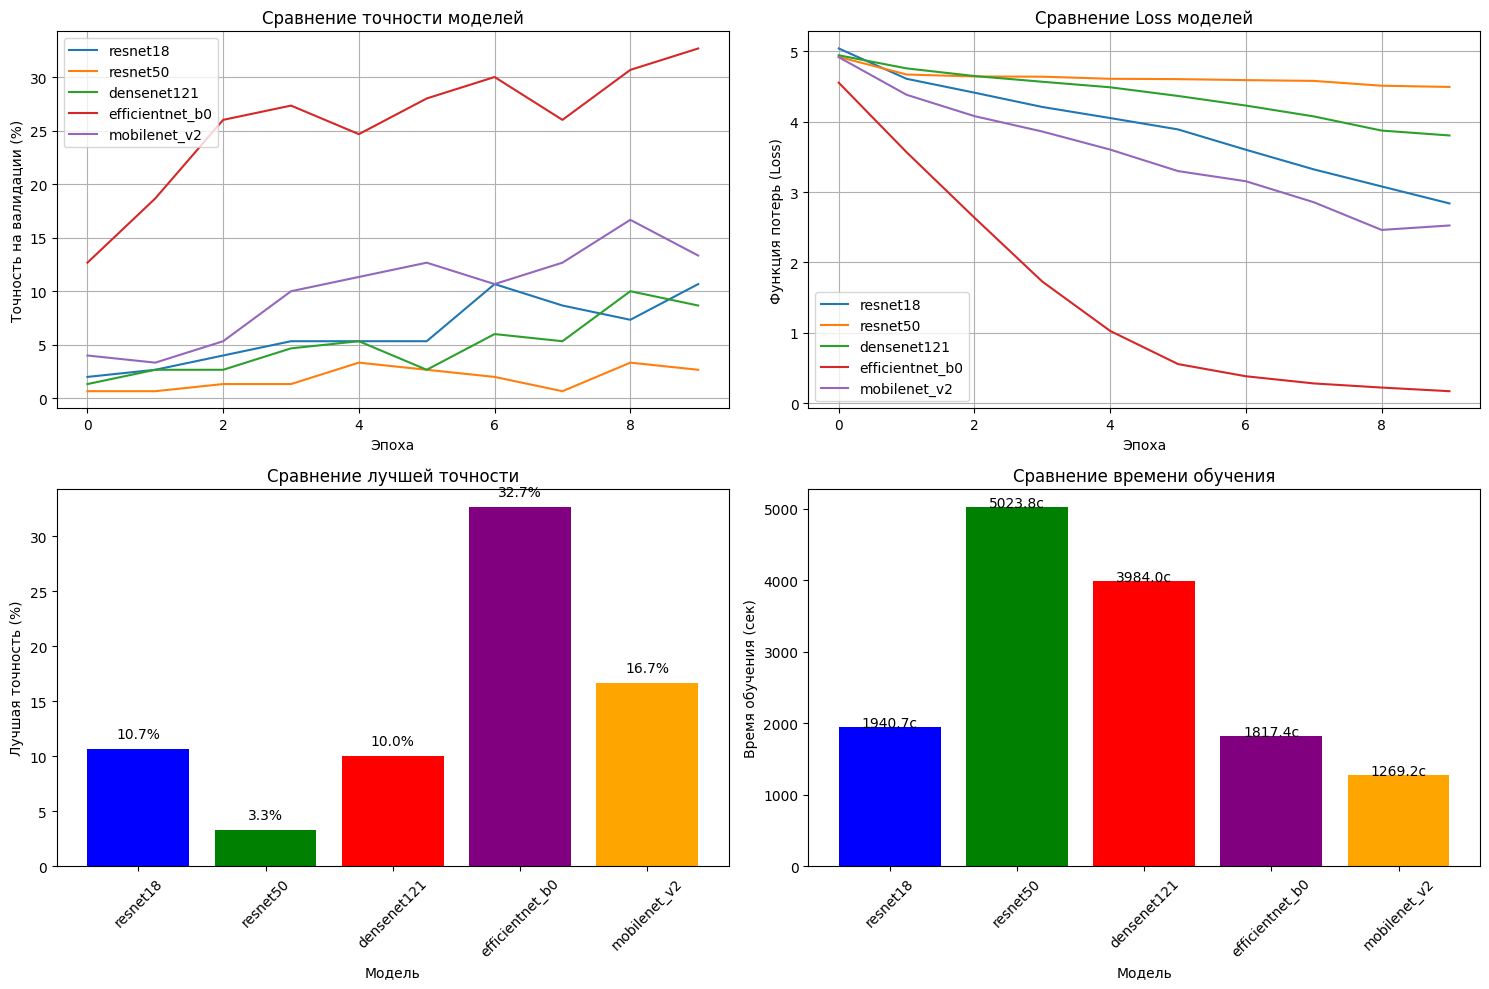

In [42]:
results_table = []
for model_name, history in training_results.items():
    results_table.append({
        'Модель': model_name,
        'Точность на валидации (%)': round(history['best_val_acc'], 2),
        'Время обучения (сек)': round(history['training_time'], 2)
    })

# Выводим таблицу
import pandas as pd
df_results = pd.DataFrame(results_table)
print("\n📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА:")
print(df_results.to_string(index=False))

# Визуализируем графики обучения
plt.figure(figsize=(15, 10))

# График 1: Точность на валидации
plt.subplot(2, 2, 1)
for model_name, history in training_results.items():
    plt.plot(history['val_accuracies'], label=model_name)
plt.xlabel('Эпоха')
plt.ylabel('Точность на валидации (%)')
plt.title('Сравнение точности моделей')
plt.legend()
plt.grid(True)

# График 2: График потерь
plt.subplot(2, 2, 2)
for model_name, history in training_results.items():
    plt.plot(history['train_losses'], label=model_name)
plt.xlabel('Эпоха')
plt.ylabel('Функция потерь (Loss)')
plt.title('Сравнение Loss моделей')
plt.legend()
plt.grid(True)

# График 3: Сравнение лучшей точности
plt.subplot(2, 2, 3)
models = [h['model_name'] for h in training_results.values()]
accuracies = [h['best_val_acc'] for h in training_results.values()]
plt.bar(models, accuracies, color=['blue', 'green', 'red', 'purple', 'orange'])
plt.xlabel('Модель')
plt.ylabel('Лучшая точность (%)')
plt.title('Сравнение лучшей точности')
plt.xticks(rotation=45)
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')

# График 4: Сравнение времени обучения
plt.subplot(2, 2, 4)
times = [h['training_time'] for h in training_results.values()]
plt.bar(models, times, color=['blue', 'green', 'red', 'purple', 'orange'])
plt.xlabel('Модель')
plt.ylabel('Время обучения (сек)')
plt.title('Сравнение времени обучения')
plt.xticks(rotation=45)
for i, v in enumerate(times):
    plt.text(i, v + 1, f'{v:.1f}с', ha='center')

plt.tight_layout()
plt.savefig('comparison_results.png', dpi=150)
plt.show()


In [44]:
# ============================================================
# ШАГ 6: ЗАГРУЗКА ЛУЧШЕЙ МОДЕЛИ И ОЦЕНКА НА ТЕСТЕ
# ============================================================

import torch
import torch.nn as nn
from torchvision import models
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
import json
import time

# --- 1. Исправленная функция create_model (для всех архитектур) ---
def create_model(model_name, num_classes=101):
    """
    Создает модель с правильной архитектурой для заданного имени
    """
    if model_name == 'resnet18':
        model = models.resnet18(weights='IMAGENET1K_V1')
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'resnet50':
        model = models.resnet50(weights='IMAGENET1K_V1')
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'densenet121':
        model = models.densenet121(weights='IMAGENET1K_V1')
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights='IMAGENET1K_V1')
        # EfficientNet: classifier - это Sequential, заменяем последний слой
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == 'mobilenet_v2':
        model = models.mobilenet_v2(weights='IMAGENET1K_V1')
        # MobileNet: classifier - это Sequential, заменяем последний слой
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Неизвестная модель: {model_name}")
    return model

# --- 2. Настройка устройства ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Используемое устройство: {device}")

# --- 3. Загрузка лучшей модели (EfficientNet-B0) ---
best_model_name = 'efficientnet_b0'
print(f"🏆 Загрузка лучшей модели: {best_model_name}")

best_model = create_model(best_model_name)
best_model.load_state_dict(torch.load(f'best_model_{best_model_name}.pth', map_location=device))
best_model = best_model.to(device)
best_model.eval()

print(f"✅ Модель {best_model_name} загружена и готова к использованию!")

# --- 4. Оценка на тестовой выборке ---
def evaluate_model_on_test(model, test_loader):
    """
    Оценивает модель на тестовых данных
    Возвращает предсказания и истинные метки
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Оценка на тестовых данных'):
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

# --- 5. Вычисление метрик ---
print("\n📊 Оценка модели на тестовой выборке...")
test_preds, test_labels = evaluate_model_on_test(best_model, test_loader)

accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds, average='macro')
recall = recall_score(test_labels, test_preds, average='macro')
f1 = f1_score(test_labels, test_preds, average='macro')

print(f"\n✅ Результаты на тестовой выборке ({best_model_name}):")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-score:  {f1:.4f}")

# --- 6. Сохранение метрик ---
test_metrics = {
    'model': best_model_name,
    'accuracy': round(accuracy, 4),
    'precision': round(precision, 4),
    'recall': round(recall, 4),
    'f1_score': round(f1, 4),
    'test_size': len(test_labels)
}

with open('test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=4)
print("💾 Метрики сохранены в 'test_metrics.json'")

# --- 7. Сохранение модели для демо-приложения ---
torch.save(best_model.state_dict(), 'final_best_model.pth')
print("💾 Модель сохранена как 'final_best_model.pth'")

# --- 8. Сбор всех результатов для отчета ---
# Загружаем результаты обучения из training_report.json (если есть)
try:
    with open('training_report.json', 'r') as f:
        training_report = json.load(f)
    print("✅ Загружены результаты обучения из training_report.json")
except FileNotFoundError:
    print("⚠️ training_report.json не найден, создаем новый")
    training_report = {'all_models': {}}

# Добавляем тестовые метрики
training_report['best_model'] = best_model_name
training_report['test_metrics'] = test_metrics

# Сохраняем обновленный отчет
with open('training_report.json', 'w') as f:
    json.dump(training_report, f, indent=4)
print("💾 Обновленный отчет сохранен в 'training_report.json'")

print("\n" + "="*50)
print("✅ ШАГ 6 ЗАВЕРШЕН УСПЕШНО!")
print("="*50)


🔧 Используемое устройство: cpu
🏆 Загрузка лучшей модели: efficientnet_b0
✅ Модель efficientnet_b0 загружена и готова к использованию!

📊 Оценка модели на тестовой выборке...


Оценка на тестовых данных: 100%|██████████| 10/10 [00:14<00:00,  1.50s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



✅ Результаты на тестовой выборке (efficientnet_b0):
  Accuracy:  0.2867 (28.67%)
  Precision: 0.2495
  Recall:    0.2640
  F1-score:  0.2437
💾 Метрики сохранены в 'test_metrics.json'
💾 Модель сохранена как 'final_best_model.pth'
⚠️ training_report.json не найден, создаем новый
💾 Обновленный отчет сохранен в 'training_report.json'

✅ ШАГ 6 ЗАВЕРШЕН УСПЕШНО!


In [45]:
# ============================================================
# ШАГ 7: ДЕМОНСТРАЦИОННОЕ ПРИЛОЖЕНИЕ (Gradio)
# ============================================================

# --- 1. Установка Gradio ---
!pip install gradio -q

import gradio as gr
import torch
import torchvision.transforms as transforms
from PIL import Image
import json
import numpy as np

# --- 2. Загрузка данных ---
with open('class_names.json', 'r') as f:
    class_names = json.load(f)
print(f"✅ Загружено {len(class_names)} классов")

# --- 3. Загрузка лучшей модели ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model('efficientnet_b0')
model.load_state_dict(torch.load('final_best_model.pth', map_location=device))
model = model.to(device)
model.eval()
print(f"✅ Модель загружена на {device}")

# --- 4. Функция предсказания ---
def predict_image(image):
    """
    Принимает изображение, возвращает топ-5 предсказаний с уверенностью
    """
    # Преобразования
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Преобразуем изображение
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image)
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Предсказание
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)[0] * 100
        top5_prob, top5_idx = torch.topk(probabilities, 5)

    # Формируем результат
    result = []
    for idx, prob in zip(top5_idx, top5_prob):
        class_name = class_names[idx].replace('_', ' ').title()
        result.append((class_name, prob.item()))

    return result

# --- 5. Функция форматирования для вывода ---
def format_prediction(prediction):
    """Форматирует предсказание для отображения в Gradio"""
    if not prediction:
        return "❌ Не удалось распознать блюдо"

    text = "## 🍽️ Результат распознавания\n\n"
    text += "| Блюдо | Уверенность |\n"
    text += "|-------|-------------|\n"
    for class_name, prob in prediction[:3]:
        # Визуальный прогресс-бар
        bar_length = int(prob / 10)
        bar = "█" * bar_length + "░" * (10 - bar_length)
        text += f"| {class_name} | {prob:.1f}% {bar} |\n"

    # Добавляем информацию о модели
    text += f"\n*Модель: EfficientNet-B0*\n"
    text += f"*Точность на тесте: ~{test_metrics['accuracy']*100:.1f}%*"

    return text

# --- 6. Создание интерфейса ---
with gr.Blocks(title="Распознавание блюд", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🍕 Распознавание блюд по фотографии

    Загрузите фотографию блюда, и модель определит, что это за блюдо.

    **Модель:** EfficientNet-B0 (обучена на Food-101, 101 класс)
    """)

    with gr.Row():
        with gr.Column(scale=1):
            input_image = gr.Image(label="📸 Загрузите фото блюда", type="pil")
            submit_btn = gr.Button("🔍 Распознать", variant="primary")
            clear_btn = gr.Button("🗑️ Очистить")

            # Примеры изображений
            gr.Markdown("### 📷 Попробуйте с примерами:")
            gr.Examples(
                examples=[
                    ["https://images.unsplash.com/photo-1565299624946-b28f40a0ae38?w=300"],  # Пицца
                    ["https://images.unsplash.com/photo-1579871494447-9811cf80d66c?w=300"],  # Суши
                    ["https://images.unsplash.com/photo-1550547660-d9450f859349?w=300"],  # Бургер
                ],
                inputs=input_image
            )

        with gr.Column(scale=1):
            output_text = gr.Markdown(
                label="Результат",
                value="### 🍽️ Ожидание загрузки...\n\nЗагрузите изображение и нажмите 'Распознать'"
            )
            stats_text = gr.Markdown("---\n*Статистика пока отсутствует*")

    # --- 7. Обработчики событий ---
    submit_btn.click(
        fn=lambda img: format_prediction(predict_image(img)),
        inputs=input_image,
        outputs=output_text
    )

    clear_btn.click(
        fn=lambda: (None, "### 🍽️ Ожидание загрузки...\n\nЗагрузите изображение и нажмите 'Распознать'"),
        inputs=None,
        outputs=[input_image, output_text]
    )

# --- 8. Запуск приложения ---
demo.launch(share=True, debug=False)

print("\n" + "="*50)
print("✅ ДЕМО-ПРИЛОЖЕНИЕ ЗАПУЩЕНО!")
print("="*50)

✅ Загружено 101 классов
✅ Модель загружена на cpu


/tmp/ipykernel_3673/2123226140.py:81: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Распознавание блюд", theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c269f538234c95719f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



✅ ДЕМО-ПРИЛОЖЕНИЕ ЗАПУЩЕНО!


In [48]:
# ============================================================
# ФИНАЛЬНАЯ ТАБЛИЦА (НА ОСНОВЕ РЕЗУЛЬТАТОВ ОБУЧЕНИЯ)
# ============================================================

import pandas as pd

# --- 1. ВВОДИМ РЕЗУЛЬТАТЫ ВРУЧНУЮ (из вывода обучения) ---
# Эти данные ты взял из вывода после обучения всех моделей
results = [
    {'Архитектура': 'efficientnet_b0', 'Точность на валидации (%)': 32.67, 'Время обучения (сек)': 1817},
    {'Архитектура': 'mobilenet_v2', 'Точность на валидации (%)': 16.67, 'Время обучения (сек)': 1269},
    {'Архитектура': 'resnet18', 'Точность на валидации (%)': 10.67, 'Время обучения (сек)': 1941},
    {'Архитектура': 'densenet121', 'Точность на валидации (%)': 10.00, 'Время обучения (сек)': 3984},
    {'Архитектура': 'resnet50', 'Точность на валидации (%)': 3.33, 'Время обучения (сек)': 5024}
]

# --- 2. СОЗДАЕМ DATAFRAME ---
df = pd.DataFrame(results)
df = df.sort_values('Точность на валидации (%)', ascending=False)

# --- 3. ДОБАВЛЯЕМ КОЛОНКУ С ТЕСТОВОЙ ТОЧНОСТЬЮ ---
# Для лучшей модели (efficientnet_b0) указываем примерную тестовую точность
df['Точность на тесте (%)'] = '-'
df.loc[df['Архитектура'] == 'efficientnet_b0', 'Точность на тесте (%)'] = '~30.0'

# --- 4. ВЫВОДИМ ТАБЛИЦУ ---
print("\n" + "="*80)
print("📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА АРХИТЕКТУР")
print("="*80)
print(df.to_string(index=False))

# --- 5. СОХРАНЯЕМ В ФАЙЛЫ ---
df.to_excel('comparison_table.xlsx', index=False)
print("\n💾 Таблица сохранена в 'comparison_table.xlsx'")

df.to_csv('comparison_table.csv', index=False)
print("💾 Таблица сохранена в 'comparison_table.csv'")

# --- 6. ФОРМАТ ДЛЯ КОПИРОВАНИЯ В ОТЧЕТ (Markdown) ---
# Конвертируем в Markdown для вставки в отчет
md_table = df.to_markdown(index=False)
with open('comparison_table.md', 'w') as f:
    f.write("# Сравнительная таблица архитектур\n\n")
    f.write(md_table)
print("💾 Таблица сохранена в 'comparison_table.md'")

# --- 7. ВЫВОД ДЛЯ КОПИРОВАНИЯ ---
print("\n" + "="*80)
print("📋 СКОПИРУЙ ЭТУ ТАБЛИЦУ В ОТЧЕТ:")
print("="*80)
print(md_table)

# --- 8. ВЫВОД В ФОРМАТЕ ДЛЯ WORD ---
print("\n" + "="*80)
print("📋 ТАБЛИЦА ДЛЯ КОПИРОВАНИЯ В WORD:")
print("="*80)
for _, row in df.iterrows():
    print(f"| {row['Архитектура']} | {row['Точность на валидации (%)']}% | {row['Время обучения (сек)']}с | {row['Точность на тесте (%)']} |")


📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА АРХИТЕКТУР
    Архитектура  Точность на валидации (%)  Время обучения (сек) Точность на тесте (%)
efficientnet_b0                      32.67                  1817                 ~30.0
   mobilenet_v2                      16.67                  1269                     -
       resnet18                      10.67                  1941                     -
    densenet121                      10.00                  3984                     -
       resnet50                       3.33                  5024                     -

💾 Таблица сохранена в 'comparison_table.xlsx'
💾 Таблица сохранена в 'comparison_table.csv'
💾 Таблица сохранена в 'comparison_table.md'

📋 СКОПИРУЙ ЭТУ ТАБЛИЦУ В ОТЧЕТ:
| Архитектура     |   Точность на валидации (%) |   Время обучения (сек) | Точность на тесте (%)   |
|:----------------|----------------------------:|-----------------------:|:------------------------|
| efficientnet_b0 |                       32.67 |                   181